## Import Libraries

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats

src = "../data/MentalHealthSurvey_new.csv"

## Load Data

In [24]:
df = pd.read_csv(src)
df.head()

,gender,age,university,degree_level,degree_major,academic_year,cgpa,residential_status,campus_discrimination,sports_engagement,...,study_satisfaction,academic_workload,academic_pressure,financial_concerns,social_relationships,depression,anxiety,isolation,future_insecurity,stress_relief_activities
0,Female,17,PU,Undergraduate,Computer Science,1st year,3.5-4.0,On-Campus,No,No Sports,...,4,5,5,5,1,5,5,5,3,Sleep
1,Female,17,PU,Undergraduate,Computer Science,1st year,3.5-4.0,On-Campus,No,No Sports,...,4,4,4,5,3,4,4,5,2,Religious Activities
2,Male,17,PU,Undergraduate,Information Technology,1st year,0.0-0.0,Off-Campus,No,7+ times,...,3,5,5,1,3,4,4,4,5,Outdoor Activities
3,Male,18,PU,Undergraduate,Data Science,1st year,2.5-3.0,Off-Campus,No,4-6 times,...,4,3,4,4,4,3,4,4,2,"Sports and Fitness, Creative Outlets, Online E..."
4,Male,18,PU,Undergraduate,Data Science,1st year,3.5-4.0,Off-Campus,No,No Sports,...,5,3,1,1,3,1,2,2,1,Sleep


## Exploratory Data Analysis

In [25]:
# Check dataset if it needs cleaning or not
print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 87 entries, 0 to 86
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   gender                    87 non-null     str  
 1   age                       87 non-null     int64
 2   university                87 non-null     str  
 3   degree_level              87 non-null     str  
 4   degree_major              87 non-null     str  
 5   academic_year             87 non-null     str  
 6   cgpa                      87 non-null     str  
 7   residential_status        87 non-null     str  
 8   campus_discrimination     87 non-null     str  
 9   sports_engagement         87 non-null     str  
 10  average_sleep             87 non-null     str  
 11  study_satisfaction        87 non-null     int64
 12  academic_workload         87 non-null     int64
 13  academic_pressure         87 non-null     int64
 14  financial_concerns        87 non-null     int64
 15  so

In [26]:
for col in df.columns:
    print(f"checking {col} column")
    print(df[col].unique())
    print("-" * 50)

checking gender column
<StringArray>
['Female', 'Male']
Length: 2, dtype: str
--------------------------------------------------
checking age column
[17 18 19 20 21 22 23 26]
--------------------------------------------------
checking university column
<StringArray>
['PU', 'NUST', 'UOL', 'UET', 'FAST', 'COMSATS', 'UMT', 'VU', 'KUST']
Length: 9, dtype: str
--------------------------------------------------
checking degree_level column
<StringArray>
['Undergraduate', 'Postgraduate']
Length: 2, dtype: str
--------------------------------------------------
checking degree_major column
<StringArray>
[      'Computer Science', 'Information Technology',           'Data Science',
   'Software Engineering']
Length: 4, dtype: str
--------------------------------------------------
checking academic_year column
<StringArray>
['1st year', '2nd year', '3rd year', '4th year']
Length: 4, dtype: str
--------------------------------------------------
checking cgpa column
<StringArray>
['3.5-4.0', '0.0-0

In [27]:
# Check if the 0.0 cgpa is a valid value or not
anomalies = df[df["cgpa"] == '0.0-0.0']

print(len(anomalies))
print(anomalies["academic_year"].value_counts())

# -> small amount, and they are all in the 1st year, so we can drop them
df = df[df["cgpa"] != '0.0-0.0']
print(df.info()) # dataset after dropping invalid values

5
academic_year
1st year    5
Name: count, dtype: int64
<class 'pandas.DataFrame'>
Index: 82 entries, 0 to 86
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   gender                    82 non-null     str  
 1   age                       82 non-null     int64
 2   university                82 non-null     str  
 3   degree_level              82 non-null     str  
 4   degree_major              82 non-null     str  
 5   academic_year             82 non-null     str  
 6   cgpa                      82 non-null     str  
 7   residential_status        82 non-null     str  
 8   campus_discrimination     82 non-null     str  
 9   sports_engagement         82 non-null     str  
 10  average_sleep             82 non-null     str  
 11  study_satisfaction        82 non-null     int64
 12  academic_workload         82 non-null     int64
 13  academic_pressure         82 non-null     int64
 14  fina

In [28]:
# Splitting the stress_relief_activities column to each individual activity
activities = df["stress_relief_activities"].str.get_dummies(sep=", ")

df = pd.concat([df, activities], axis=1)
df = df.drop("stress_relief_activities", axis=1)

# renaming the activity columns to be more descriptive
activity_list = activities.columns.tolist()
new_activity_names = [f"activity_{activity.strip().lower().replace(' ', '_')}" for activity in activity_list]
activities.columns = new_activity_names

# update the main dataframe with the new activity column names
df = df.drop(activity_list, axis=1)  # drop old activity columns
df = pd.concat([df, activities], axis=1)  # add new activity columns

print(activities.columns)
df.head()

Index(['activity_creative_outlets', 'activity_nothing',
       'activity_online_entertainment', 'activity_outdoor_activities',
       'activity_religious_activities', 'activity_sleep',
       'activity_social_connections', 'activity_sports_and_fitness'],
      dtype='str')


,gender,age,university,degree_level,degree_major,academic_year,cgpa,residential_status,campus_discrimination,sports_engagement,...,isolation,future_insecurity,activity_creative_outlets,activity_nothing,activity_online_entertainment,activity_outdoor_activities,activity_religious_activities,activity_sleep,activity_social_connections,activity_sports_and_fitness
0,Female,17,PU,Undergraduate,Computer Science,1st year,3.5-4.0,On-Campus,No,No Sports,...,5,3,0,0,0,0,0,1,0,0
1,Female,17,PU,Undergraduate,Computer Science,1st year,3.5-4.0,On-Campus,No,No Sports,...,5,2,0,0,0,0,1,0,0,0
3,Male,18,PU,Undergraduate,Data Science,1st year,2.5-3.0,Off-Campus,No,4-6 times,...,4,2,1,0,1,1,0,0,0,1
4,Male,18,PU,Undergraduate,Data Science,1st year,3.5-4.0,Off-Campus,No,No Sports,...,2,1,0,0,0,0,0,1,0,0
5,Male,18,PU,Undergraduate,Data Science,1st year,1.5-2.0,On-Campus,No,No Sports,...,4,4,0,0,0,0,1,0,0,0


depression
5    20
4    18
3    18
1    13
2    13
Name: count, dtype: int64


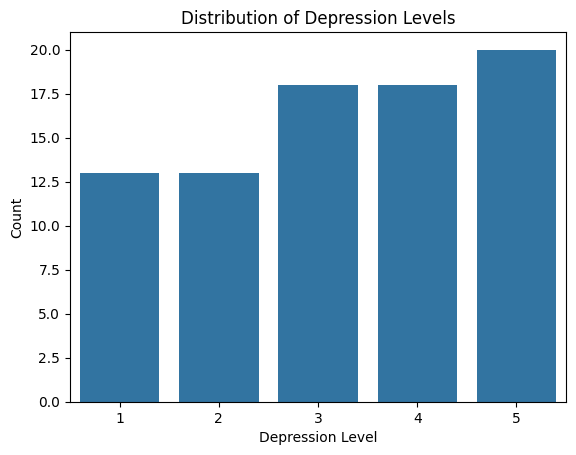

In [29]:
# Data visualization
# distribution of depression levels
print(df["depression"].value_counts())
sns.countplot(x="depression", data=df)
plt.title("Distribution of Depression Levels")
plt.xlabel("Depression Level")
plt.ylabel("Count")
plt.show()


Correlation between features

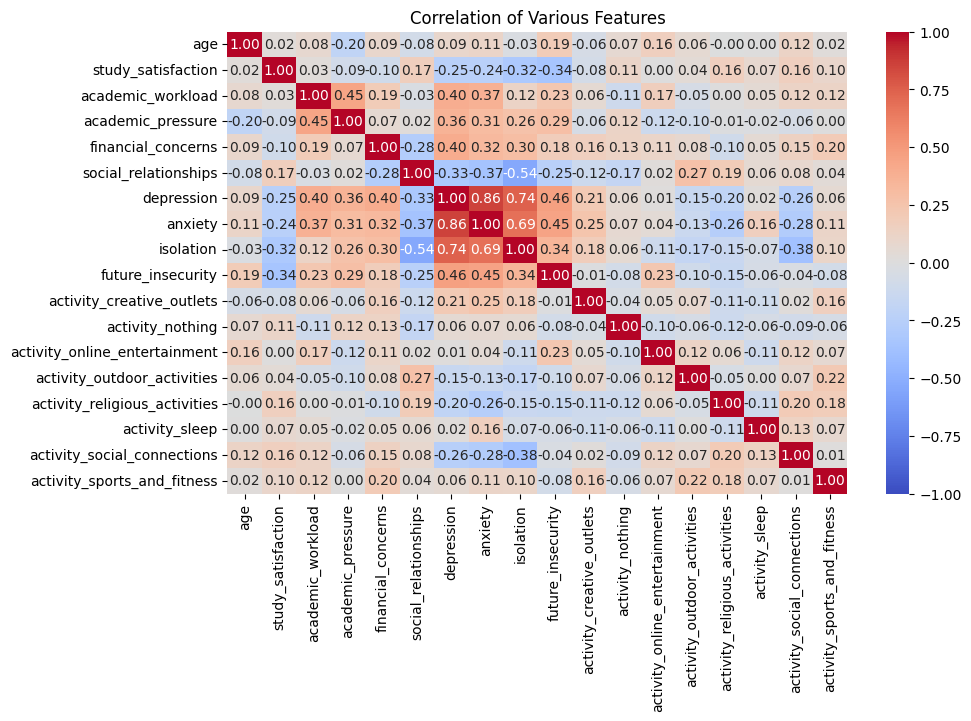

In [30]:
# splitting the dataset to each type features
numerical_features = df.select_dtypes(include=['int64', 'float64', 'int32'])

# selecting the depression feature
depression_corr = numerical_features.corr()[["depression"]].sort_values(by="depression", ascending=False)

# data visualization
plt.figure(figsize=(10, 6))
sns.heatmap(numerical_features.corr(), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation of Various Features")
plt.show()

Relation between GPA and Academic Pressure

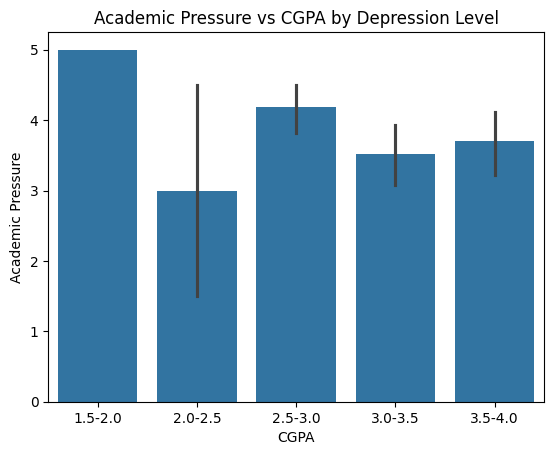

      cgpa  students  mean_academic_pressure  bottom_ci  top_ci  error_margin
0  1.5-2.0         2                    5.00        NaN     NaN           NaN
1  2.0-2.5         4                    3.00       0.09    5.91          2.91
2  2.5-3.0        22                    4.18       3.80    4.56          0.38
3  3.0-3.5        27                    3.52       3.07    3.96          0.44
4  3.5-4.0        27                    3.70       3.23    4.18          0.48


C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\scipy\stats\_distn_infrastructure.py:2334: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\scipy\stats\_distn_infrastructure.py:2335: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


In [ ]:
gpa_order = sorted(df['cgpa'].unique().tolist())

sns.barplot(x='cgpa', y='academic_pressure', data=df, order=gpa_order)
plt.title('Academic Pressure vs CGPA by Depression Level')
plt.xlabel('CGPA')
plt.ylabel('Academic Pressure')
plt.show()

# calculate the confidence intervals with 95% confidence level for the mean academic pressure for each CGPA group using the t-distribution (small sample size)
confidence_results = []
for gpa in gpa_order:
    data = df[df['cgpa'] == gpa]['academic_pressure'].dropna()
    n = len(data)

    if n > 1: 
        mean = np.mean(data)
        variance = stats.sem(data)  # sample variance
        ci = stats.t.interval(0.95, df=n-1, loc=mean, scale=variance)
        error_margin = (ci[1] - ci[0]) / 2

        confidence_results.append({
            'cgpa': gpa,
            'students': n,
            'mean_academic_pressure': round(mean,2),
            'bottom_ci': round(ci[0],2),
            'top_ci': round(ci[1],2),
            'error_margin': round(error_margin,2)
        })

stats_df = pd.DataFrame(confidence_results)
print(stats_df)


Checking what is the most effective activities to fight back depression

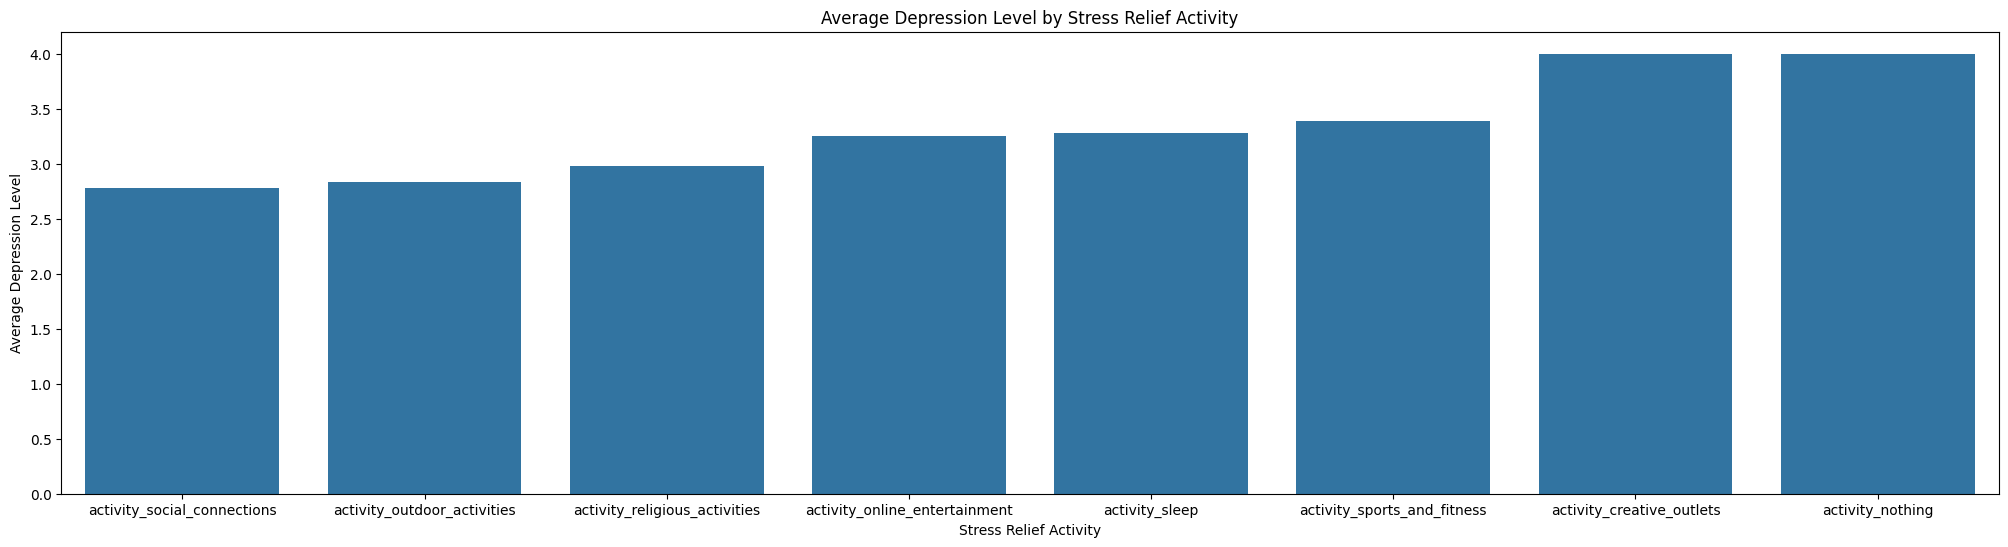

activity_social_connections      2.774194
activity_outdoor_activities      2.833333
activity_religious_activities    2.977778
activity_online_entertainment    3.250000
activity_sleep                   3.277778
activity_sports_and_fitness      3.388889
activity_creative_outlets        4.000000
activity_nothing                 4.000000
dtype: float64


In [40]:
activities_score = {}
for activity in activities.columns:
    # fetch all students who do this activity
    students = df[df[activity] == 1]
    avg_depression = students['depression'].mean()
    activities_score[activity] = avg_depression

# display results
result = pd.Series(activities_score).sort_values()
# data visualization
plt.figure(figsize=(25, 6))
sns.barplot(x=result.index, y=result.values)
plt.title('Average Depression Level by Stress Relief Activity')
plt.xlabel('Stress Relief Activity')
plt.ylabel('Average Depression Level')
plt.show()
print(result)

Does being poor on-campus or off-campus effect the level of depression?

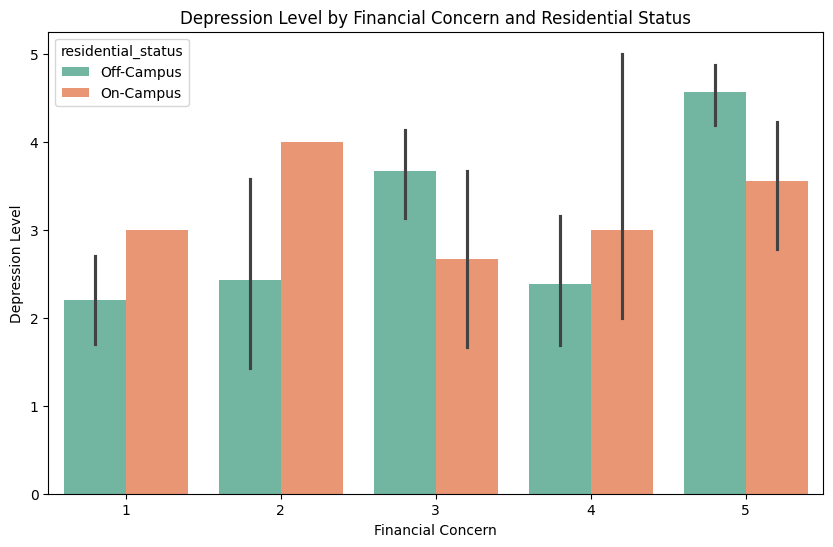

C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\scipy\stats\_distn_infrastructure.py:2334: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\scipy\stats\_distn_infrastructure.py:2335: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


,residential_status,financial_concerns,students,mean_depression,bottom_ci,top_ci,error_margin
0,On-Campus,1,2,3.00,NaN,NaN,NaN
1,On-Campus,3,6,2.67,1.09,4.25,1.58
2,On-Campus,4,3,3.00,-1.30,7.30,4.30
3,On-Campus,5,9,3.56,2.61,4.51,0.95
4,Off-Campus,1,10,2.20,1.54,2.86,0.66
5,Off-Campus,2,7,2.43,0.93,3.93,1.50
6,Off-Campus,3,15,3.67,3.09,4.25,0.58
7,Off-Campus,4,13,2.38,1.55,3.22,0.84
8,Off-Campus,5,16,4.56,4.17,4.95,0.39


In [45]:
plt.figure(figsize=(10, 6))
sns.barplot(x='financial_concerns', y='depression', hue='residential_status', data=df, palette='Set2')
plt.title('Depression Level by Financial Concern and Residential Status')
plt.xlabel('Financial Concern')
plt.ylabel('Depression Level')
plt.show()

# statistical test for the error margin (t-test with 95% confidence level)
test_results = []
for status in df['residential_status'].unique():
    for concern in sorted(df['financial_concerns'].unique()):
        group = df[(df['residential_status'] == status) & (df['financial_concerns'] == concern)]['depression'].dropna()
        if len(group) > 1:
            mean = np.mean(group)
            variance = stats.sem(group)  # sample variance
            ci = stats.t.interval(0.95, df=len(group)-1, loc=mean, scale=variance)
            error_margin = (ci[1] - ci[0]) / 2

            test_results.append({
                'residential_status': status,
                'financial_concerns': concern,
                'students': len(group),
                'mean_depression': round(mean,2),
                'bottom_ci': round(ci[0],2),
                'top_ci': round(ci[1],2),
                'error_margin': round(error_margin,2)
            })

test_df = pd.DataFrame(test_results)
test_df

Average stat of a least depressed student vs stat of a most depressed student

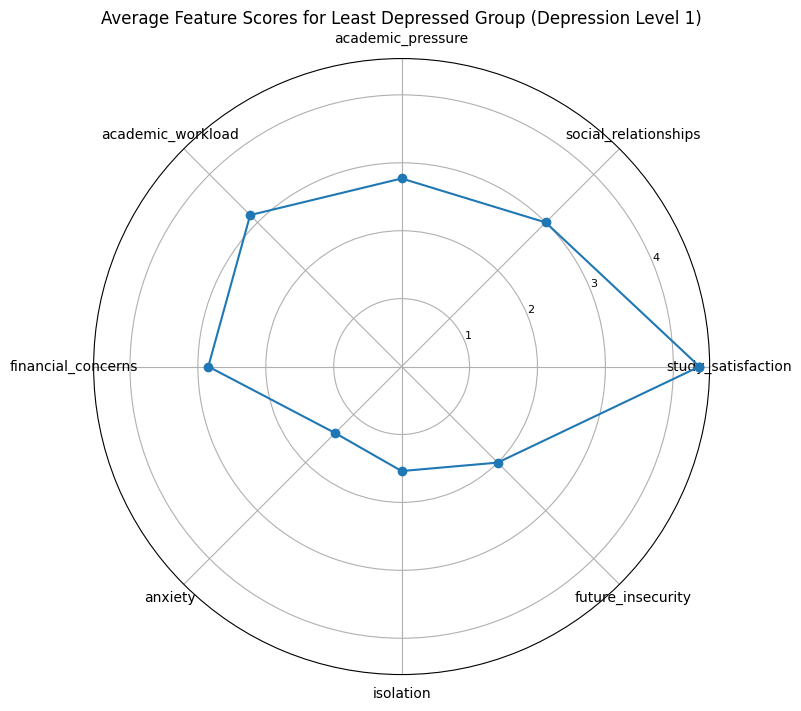

study_satisfaction: 4.38
social_relationships: 3.00
academic_pressure: 2.77
academic_workload: 3.15
financial_concerns: 2.85
anxiety: 1.38
isolation: 1.54
future_insecurity: 2.00


In [56]:
# radar chart for the average of all features by the least depressed group (depression level 1)
least_depressed = df[df['depression'] == 1]
features = ['study_satisfaction', 'social_relationships', 'academic_pressure', 'academic_workload', 'financial_concerns', 'anxiety', 'isolation', 'future_insecurity']
average_features = least_depressed[features].mean().tolist()
average_features.append(average_features[0])  # to close the radar chart
plt.figure(figsize=(8, 8))
angles = np.linspace(0, 2 * np.pi, len(features) + 1, endpoint=True)
plt.polar(angles, average_features, marker='o')
plt.title('Average Feature Scores for Least Depressed Group (Depression Level 1)')
plt.xticks(angles[:-1], features, fontsize=10)
plt.yticks(fontsize=8)
plt.show()
for feature, score in zip(features, average_features[:-1]):
    print(f"{feature}: {score:.2f}")

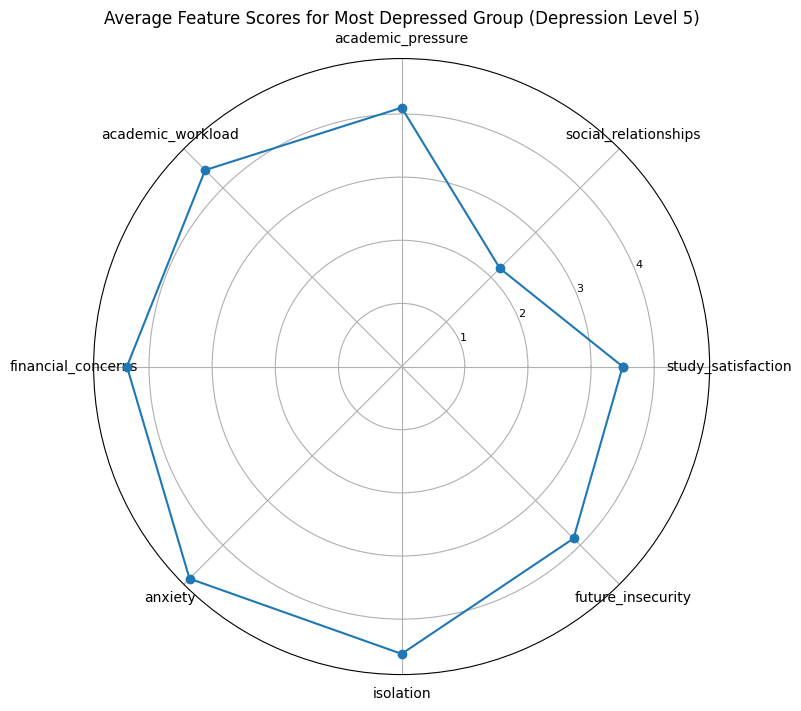

study_satisfaction: 3.50
social_relationships: 2.20
academic_pressure: 4.10
academic_workload: 4.40
financial_concerns: 4.35
anxiety: 4.75
isolation: 4.55
future_insecurity: 3.85


In [57]:
# radar chart for the average of all features by the most depressed group (depression level 5)
most_depressed = df[df['depression'] == 5]
average_features_most = most_depressed[features].mean().tolist()
average_features_most.append(average_features_most[0])  # to close the radar chart
plt.figure(figsize=(8, 8))
angles = np.linspace(0, 2 * np.pi, len(features) + 1, endpoint=True)
plt.polar(angles, average_features_most, marker='o')
plt.title('Average Feature Scores for Most Depressed Group (Depression Level 5)')
plt.xticks(angles[:-1], features, fontsize=10)
plt.yticks(fontsize=8)
plt.show()
for feature, score in zip(features, average_features_most[:-1]):
    print(f"{feature}: {score:.2f}")